# 06 — Whole-ROI Kinetic Model Fitting

This notebook fits DCE-MRI pharmacokinetic models to a whole-ROI mean concentration curve.

Instead of fitting each voxel independently, the signal across all ROI voxels is pooled
into a single mean curve and the kinetic model is fit to that curve.

**Contents**
1. Setup and data loading
2. AIF inspection
3. ROI aggregation — signal vs concentration space comparison
4. Model fitting — TCXM and GKM without delay
5. Model fitting with AIF time delay — grid search
6. Model fitting with AIF time delay — continuous optimisation
7. Cost comparison — no delay vs grid vs continuous
8. Multi-ROI fitting (if segmentation available)

**When to use ROI fitting vs voxelwise fitting**
- ROI fitting: low SNR data, quick sanity check, heterogeneity analysis
- Voxelwise fitting: high SNR, spatial parameter maps needed

## 1. Setup and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from dce_mri.config import (
    AcquisitionConfig, SubjectConfig,
    FittingConfig, RoiFittingConfig,
    AifConfig
)

from dce_mri.kinetic_models import TCXM, GKM, tcxm_ct_analytic, gkm_ct
from dce_mri.signal_models import (
    signal_to_concentration, concentration_to_signal, shift_aif,extract_aif
)
from dce_mri.fitting_roi import (
    fit_roi,
    fit_roi_with_delay_grid,
    fit_roi_with_delay_continuous,
    fit_multi_roi,
    _aggregate_roi_signal,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [33]:
# ── Option A: use synthetic data (default — no files needed) ──────────
USE_SYNTHETIC = False   # set False to load real data below

acq     = AcquisitionConfig(TR=3.64, FA=10.0, r1=3.8,nbase=slice(0,3))
subject = SubjectConfig("test", T10=1530.0, B1=1.0)
cfg     = FittingConfig(n_lhs=200, n_top=10)

if USE_SYNTHETIC:
    # synthetic gamma-variate AIF with 30s baseline
    t   = np.linspace(0, 300, 90)
    t_b = t - 30.0
    aif = np.clip(((t_b/15)**4) * np.exp(-4*(t_b/15 - 1)), 0, None)
    aif[:9] = 0.0
    aif /= aif.max()

    # synthetic 4x4x4 volume — all voxels same signal
    # TODO: replace with real data loading
    S0 = 1000
    true_tau    = 8.4          # seconds
    shifted_aif = shift_aif(aif, true_tau, t, acq)
    Ct_true     = gkm_ct(GKM.p0, t, shifted_aif)
    sig_1d      = concentration_to_signal(Ct_true, acq, subject.T10,
                                           subject.B1, S0)
    sig_4d      = np.tile(sig_1d, (4, 4, 4, 1))
    mask        = np.ones((4, 4, 4), dtype=bool)
    seg_vol     = np.ones((4, 4, 4), dtype=int)  # single ROI label=1

    print(f"Synthetic data: {sig_4d.shape} volume, {mask.sum()} masked voxels")
    print(f"True params (TCXM): {TCXM.p0}")
    print(f"True tau: {true_tau} s")
    # --- noise settings ---
    snr_aif = 20
    snr_sig = 20    
    # --- signal noise ---
    sig_noise_std = S0 / snr_sig
    sig_4d_noisy = sig_4d + np.random.normal(0, sig_noise_std, size=sig_4d.shape)
    sig_4d_noisy = np.clip(sig_4d_noisy, 0, None)
    sig_4d = sig_4d_noisy
else:
    # ── Option B: load real data ──────────────────────────────────────
    #  edit these for each subject/dataset you load 
    from dce_mri.volume import load_nifti_canonical
    from dce_mri.io import load_aif
    
    DCE_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/FMB_21spf_PCA_NII/FMB056/NIfTI/MGRASP_temptv_FMB056_lambda_0_001.nii.gz"
    AIF_PATH  = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Aorta_RotOrtho_6.nii"
    MASK_PATH = "/mnt/winshare/Labspace/Projects/fastMRIbreast/Lesion_nii_Files/Lesions_nii/FMB056ROI/ROI/56_Lesion 3_RotOrtho_6.nii"
    
    subject = SubjectConfig(
        subject_id         = "FMB056",
        T10                = 1530.0,
        B1                 = 1.0,
        dce_path_override  = DCE_PATH,
        aif_path_override   = AIF_PATH,
        mask_path_override  = MASK_PATH,
    )
    
    sig_4d, ref_img = load_nifti_canonical(subject.dce_path)

    # Time parameters
    nspoke    = 288    # total spokes across the whole scan
    scantime  = 150     # total scan duration, seconds
    spoke_res = 21       # spokes per frame
    
    dt = scantime * spoke_res / nspoke
    t = (np.arange(sig_4d.shape[-1])) * dt
    
    # load masks — binary ROI
    mask_aif,_      = load_nifti_canonical(subject.aif_path)
    aif_ROI         = mask_aif.astype(bool)
    mask_data, _ = load_nifti_canonical(subject.mask_path)
    lesion_ROI   = mask_data.astype(bool)
    
    # optional: load segmentation for multi-ROI fitting
    # seg_vol, _ = load_nifti_canonical(subject.seg_path)

    print(f"Loaded: {sig_4d.shape} volume, {lesion_ROI.sum()} tumor voxels, {aif_ROI.sum()} aif voxels")


Synthetic data: (4, 4, 4, 90) volume, 64 masked voxels
True params (TCXM): [0.243   0.196   0.00635 0.00515]
True tau: 8.4 s


# 2. ROI inspection

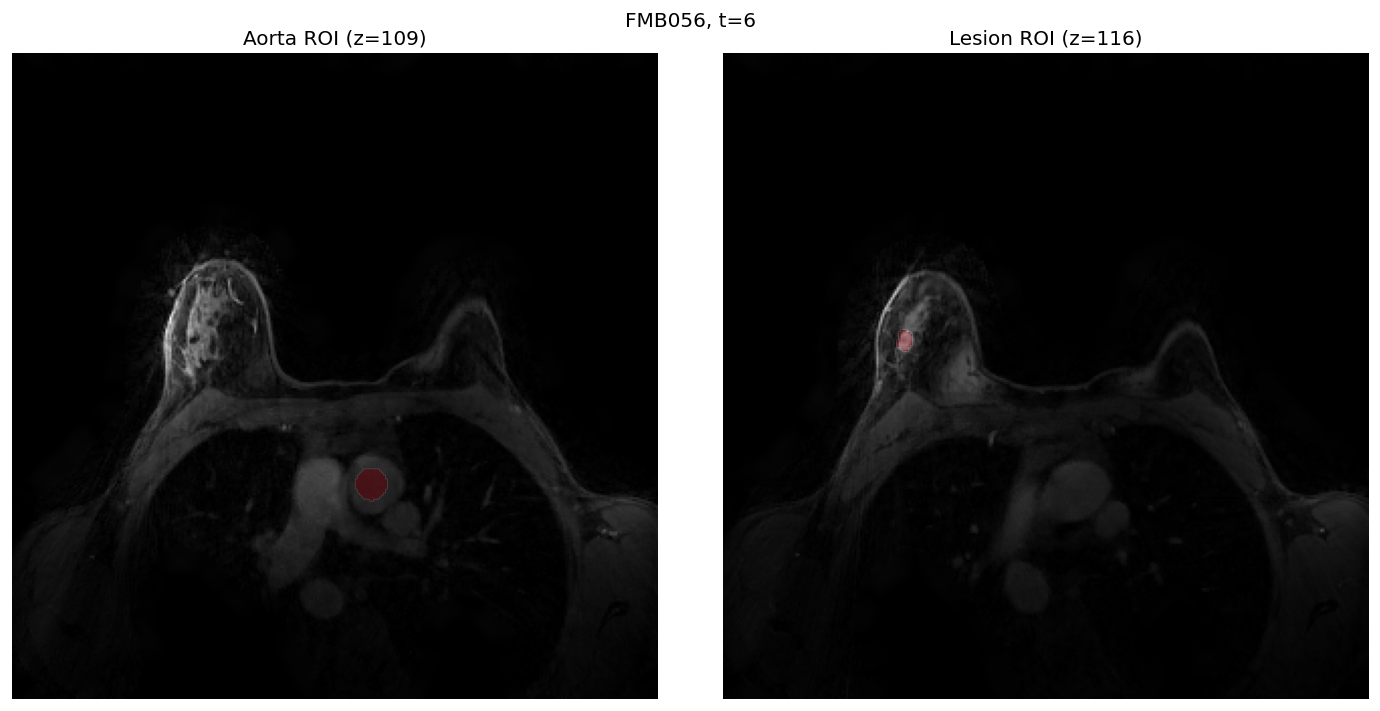

In [7]:
aif_idx = 109 
lesion_idx =116
time_idx = 6
    
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
img_aif = sig_4d[:, :, aif_idx, time_idx]
img_lesion = sig_4d[:, :, lesion_idx, time_idx]
  
axes[0].imshow(img_aif.T, cmap="gray", origin="lower")
axes[0].imshow(aif_ROI[:,:,aif_idx].T,cmap="Reds", alpha= 0.5 * aif_ROI[:,:,aif_idx].T ,origin="lower")
axes[0].set_title(f"Aorta ROI (z={aif_idx})")
axes[0].axis("off")

axes[1].imshow(img_lesion.T,cmap="gray", origin="lower")
axes[1].imshow(lesion_ROI[:,:,lesion_idx].T,cmap="Reds",alpha=0.5 * lesion_ROI[:,:,lesion_idx].T ,origin="lower")
axes[1].set_title(f"Lesion ROI (z={lesion_idx})")
axes[1].axis("off")
    
plt.suptitle(f"{subject.subject_id}, t={time_idx}")
plt.tight_layout()
plt.show()

## 3. AIF inspection
**AIF error propagation strongly affects model parameter errors.**

Dynamic contrast-enhanced MRI (DCE-MRI) signal intensities are converted to gadolinium concentration using the spoiled gradient echo (SPGR) signal equation.
For DCE-MRI, the nonlinear SPGR signal-to-concentration conversion relies on several important assumptions:

Accurate SPGR signal model
The signal follows the steady-state spoiled gradient echo equation.
Transverse coherences are fully spoiled between excitations.
TR and flip angle are known and constant throughout the acquisition.
Fast water exchange
Water molecules exchange rapidly between tissue compartments relative to the relaxation timescale (the "fast exchange limit").

**Under this assumption, a voxel can be characterized by a single effective T1**

1. Linear relaxivity relationship :Contrast agent concentration changes relaxation rate according to 
R1(t)=R10+r1C(t)
where R1=1/T1
2. The relaxivity r1 is assumed constant and known.
3. Negligible T2* effects
Signal changes are assumed to arise primarily from T1 shortening.
Susceptibility-induced T2* losses are neglected.
This assumption may break down in arteries during the first pass when contrast concentration is very high.
4. Known pre-contrast T1(T10)
The baseline T1 map is accurate.
Errors in T10 propagate directly into concentration estimates and pharmacokinetic parameters.
5. Uniform flip angle
The actual flip angle equals the prescribed flip angle.
In practice, B1 inhomogeneity can cause flip-angle errors and bias concentration estimates, especially at higher flip angles.
6. Constant proton density/scaling factor
The proportionality factor S0 does not change over time.
7. Coil sensitivity, receiver gain, and patient position are assumed stable during the scan.
8. No significant motion
The same tissue occupies each voxel throughout the dynamic acquisition.
Motion can introduce apparent signal changes unrelated to contrast uptake.

**Effect of shifting estimation on AIF shape**

The points making the AIF are interpolated to a curve and then shifted and sampled at the time points for the frame. After the shift, the values for either the head of tail of the curve are populated based on the trailing values Choosing linear vs pchip interpolation can affect the resulting AIF shape.

AIF signal range : [7.8, 50.8]
AIF plasma range : [-0.0629, 3.5480] mM


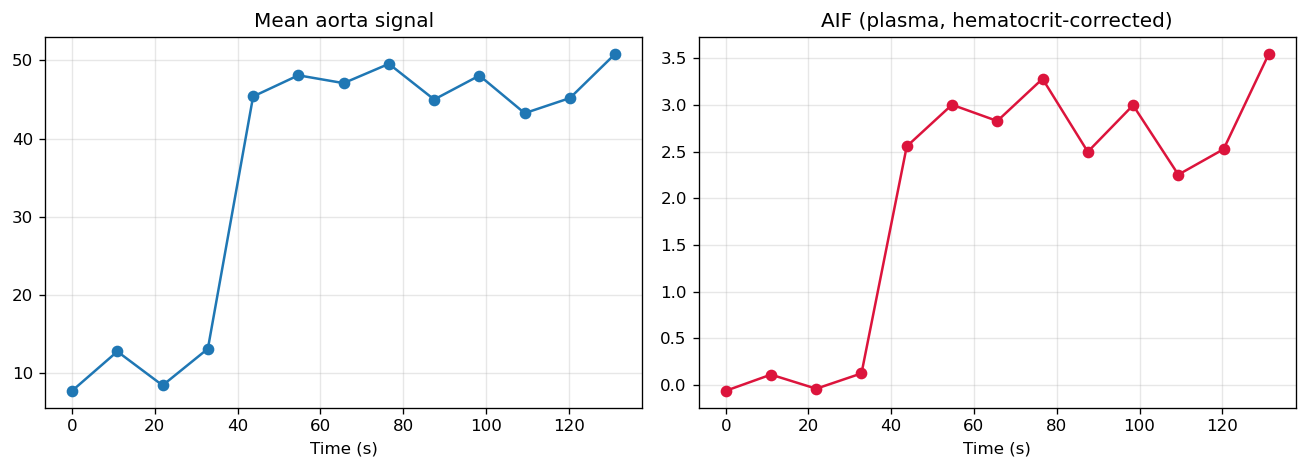

AIF peak time  : 131.2 s
AIF peak value : 3.5480 mM
AIF baseline   : 0.002528 mM


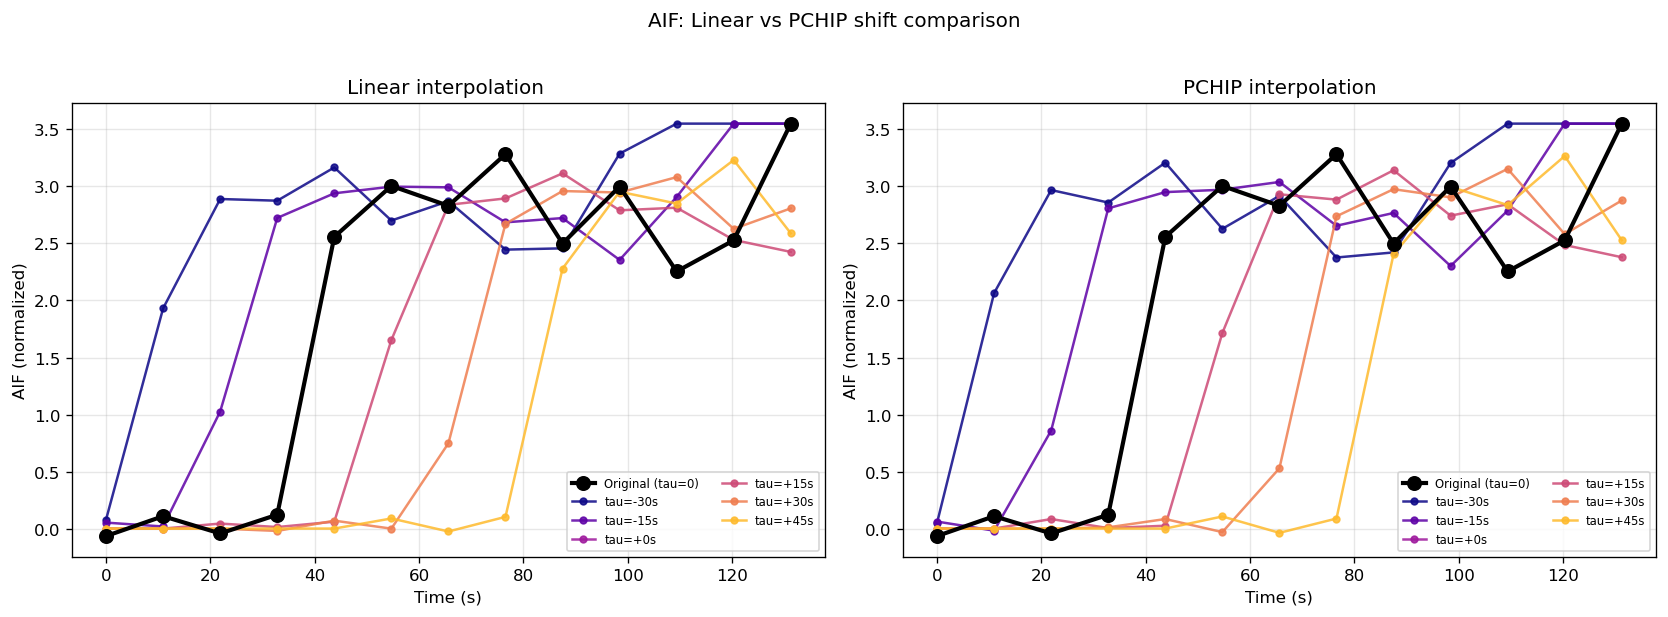

In [24]:
from dce_mri.config import AifConfig
from dce_mri.signal_models import extract_aif

# change the nbase to fit the number of base frames based on the spoke resolution
aif_cfg = AifConfig(
    T10        = 1664.0,
    hematocrit = 0.45,
    top_frac   = 1.0,
    nbase      = slice(0, 3),  
)

aif, aif_signal = extract_aif(sig_4d, aif_ROI, acq, aif_cfg, B1=subject.B1)

print(f"AIF signal range : [{aif_signal.min():.1f}, {aif_signal.max():.1f}]")
print(f"AIF plasma range : [{aif.min():.4f}, {aif.max():.4f}] mM")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, aif_signal, 'o-')
axes[0].set_title("Mean aorta signal")
axes[0].set_xlabel("Time (s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, aif, 'o-', color='crimson')
axes[1].set_title("AIF (plasma, hematocrit-corrected)")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"AIF peak time  : {t[np.argmax(aif)]:.1f} s")
print(f"AIF peak value : {aif.max():.4f} mM")
print(f"AIF baseline   : {aif[acq.nbase].mean():.6f} mM")

# How the shifing of the AIF is estimated
tau_sweep = [-30, -15, 0, 15, 30, 45]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method, title in zip(
    axes, ["linear", "pchip"],
    ["Linear interpolation ", "PCHIP interpolation"]
):
    ax.plot(t, aif, 'ko-', lw=2.5, ms=8, label='Original (tau=0)', zorder=10)
    cmap = plt.cm.plasma(np.linspace(0, 0.85, len(tau_sweep)))
    for tau, color in zip(tau_sweep, cmap):
        shifted = shift_aif(aif, tau, t, acq, method=method)
        ax.plot(t, shifted, 'o-', lw=1.5, ms=4, color=color, alpha=0.85, label=f'tau={tau:+d}s')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('AIF (normalized)')
        ax.set_title(title)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.3)
        #ax.set_ylim(-0.3, 3.2)

plt.suptitle('AIF: Linear vs PCHIP shift comparison',
                 fontsize=12, y=1.02)
plt.tight_layout()

## 4. ROI aggregation — signal vs concentration space

This notebook section demonstrates the effect of ROI averaging before and after conversion from MRI signal to gadolidium concentration. 

**Signal aggregation:** The signal across all ROI voxels is pooled into a single mean curve S(t) and converted to gadolidium concentration C(t).

**Concentration aggregation:** The ROI voxels are individually converted to gadolidium concentration. The concentration across all ROI voxels is pooled into a sigle mean curve C(t). This C(t) can be converted back to S(t) 


In [34]:
roi_cfg_sig  = RoiFittingConfig(average_space='signal')
roi_cfg_conc = RoiFittingConfig(average_space='concentration')

Ct_sig,  n_sig,  St_sig  = _aggregate_roi_signal(
    sig_4d, lesion_ROI, acq, subject, roi_cfg_sig
)
Ct_conc, n_conc, St_conc = _aggregate_roi_signal(
    sig_4d, lesion_ROI, acq, subject, roi_cfg_conc
)

St_conc = concentration_to_signal(
    Ct_conc,           # Ct from concentration-aggregation
    acq,
    T10=subject.T10,
    B1=subject.B1,
    S0=St_sig[acq.nbase].mean()   # baseline signal scale
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# signal space
axes[0].plot(t, St_sig,  'b-', lw=2, label='Signal aggregation')
axes[0].plot(t, St_conc, 'r--', lw=2, label='Concentration aggregation')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Signal (a.u.)')
axes[0].set_title('Mean ROI signal — aggregation comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# concentration space
axes[1].plot(t, Ct_sig,  'b-', lw=2, label='Signal aggregation')
axes[1].plot(t, Ct_conc, 'r--', lw=2, label='Concentration aggregation')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('CA concentration (mM)')
axes[1].set_title('Mean ROI concentration — aggregation comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Signal aggregation   : {n_sig} voxels")
print(f"  Ct range: [{Ct_sig.min():.4f}, {Ct_sig.max():.4f}] mM")
print(f"  St range: [{St_sig.min():.1f}, {St_sig.max():.1f}] a.u.")
print(f"Concentration aggregation: {n_conc} voxels")
print(f"  Ct range: [{Ct_conc.min():.4f}, {Ct_conc.max():.4f}] mM")
print(f"  St range: [{St_conc.min():.1f}, {St_conc.max():.1f}] a.u.")
print(f"Max Ct difference (sig vs conc): "
      f"{np.abs(Ct_sig - Ct_conc).max():.6f} mM")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 4 but size of corresponding boolean axis is 320

## 5. Model fitting — TCXM and GKM without delay

Fitting TCXM ...
Fitting GKM ...

── TCXM results ──────────────────────────────────
  success : True
  cost    : 5.3180e-03
  ve      : 0.00033
  vp      : 0.17402
  fp      : 0.00359
  ps      : 0.03165

── GKM results ───────────────────────────────────
  success : True
  cost    : 8.7954e-02
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.06812


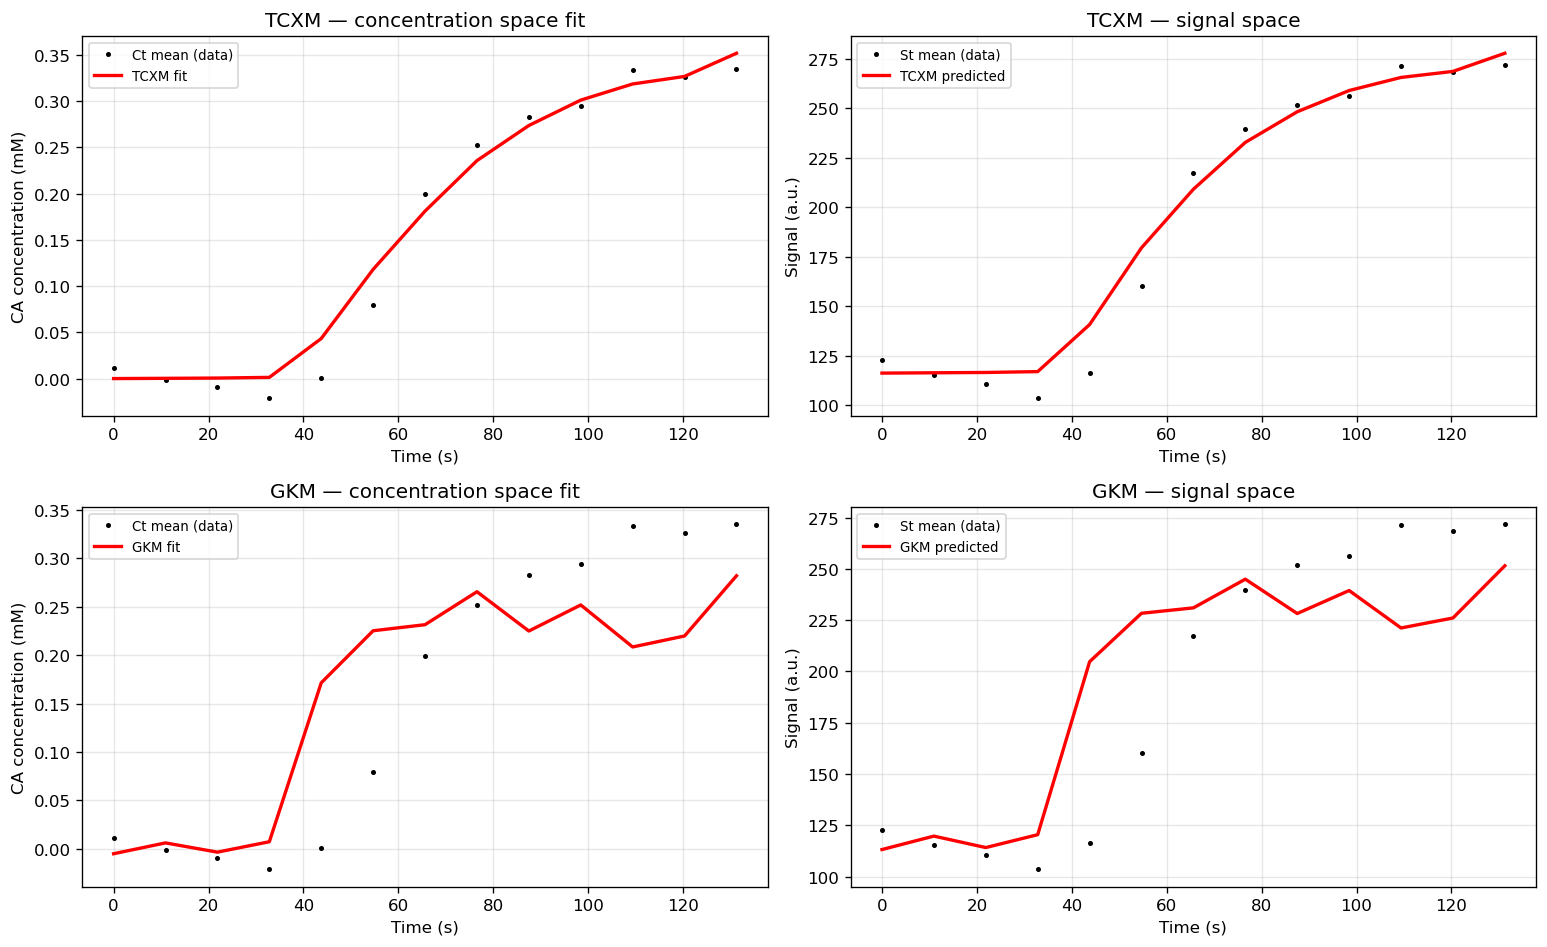

In [12]:
roi_cfg = RoiFittingConfig(average_space='signal')

print("Fitting TCXM ...")
result_tcxm = fit_roi(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg, seed=0
)

print("Fitting GKM ...")
result_gkm = fit_roi(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg, seed=0
)

print("\n── TCXM results ──────────────────────────────────")
print(f"  success : {result_tcxm.success}")
print(f"  cost    : {result_tcxm.cost:.4e}")
for name, val in zip(TCXM.param_names, result_tcxm.params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM results ───────────────────────────────────")
print(f"  success : {result_gkm.success}")
print(f"  cost    : {result_gkm.cost:.4e}")
for name, val in zip(GKM.param_names, result_gkm.params):
    print(f"  {name:8s}: {val:.5f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax_row, result, model, label in zip(
    axes,
    [result_tcxm, result_gkm],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    # concentration fit
    ax_row[0].plot(t, result.Ct_mean, 'k.', ms=4, label='Ct mean (data)')
    ax_row[0].plot(t, result.Ct_pred, 'r-', lw=2, label=f'{label} fit')
    ax_row[0].set_xlabel('Time (s)')
    ax_row[0].set_ylabel('CA concentration (mM)')
    ax_row[0].set_title(f'{label} — concentration space fit')
    ax_row[0].legend(fontsize=8)
    ax_row[0].grid(True, alpha=0.3)

    # signal fit
    ax_row[1].plot(t, result.St_mean, 'k.', ms=4, label='St mean (data)')
    ax_row[1].plot(t, result.St_pred, 'r-', lw=2, label=f'{label} predicted')
    ax_row[1].set_xlabel('Time (s)')
    ax_row[1].set_ylabel('Signal (a.u.)')
    ax_row[1].set_title(f'{label} — signal space')
    ax_row[1].legend(fontsize=8)
    ax_row[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Model fitting with AIF time delay — grid search

Grid search over 30 tau values: -10s to 48s (spacing 2s)

Fitting TCXM + grid delay ...
Fitting GKM + grid delay ...

── TCXM + grid delay ─────────────────────────────
  success      : True
  cost         : 1.2509e-03
  best tau     : 16.0 s
  ve      : 0.22783
  vp      : 0.06659
  fp      : 0.02719
  ps      : 0.00099

── GKM + grid delay ──────────────────────────────
  success      : True
  cost         : 1.4160e-02
  best tau     : 18.0 s
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.07425


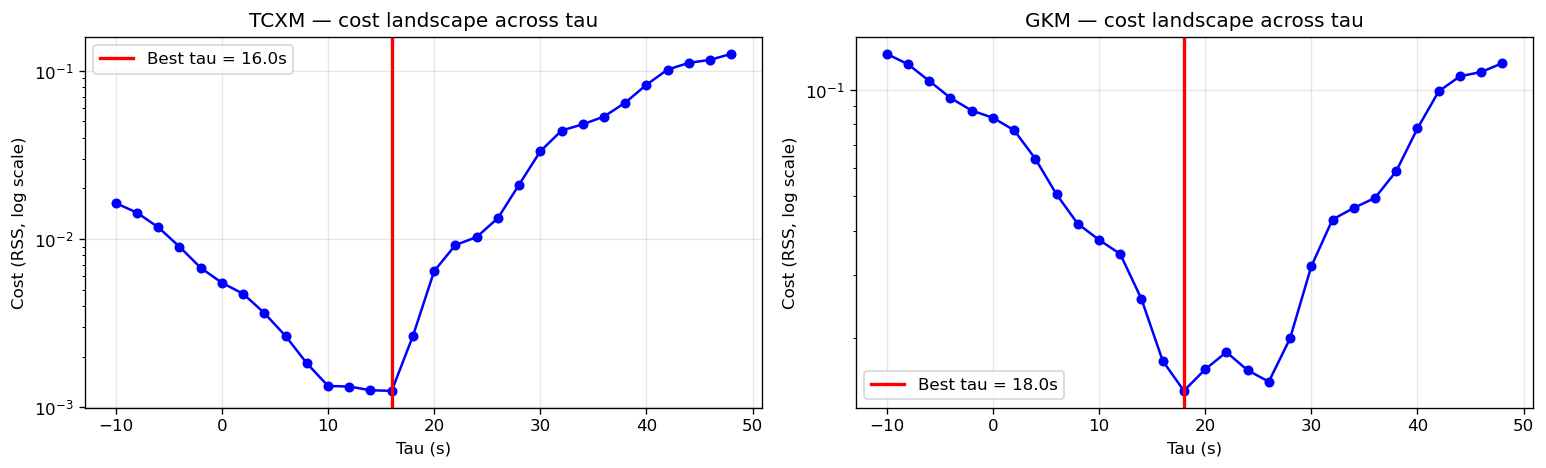

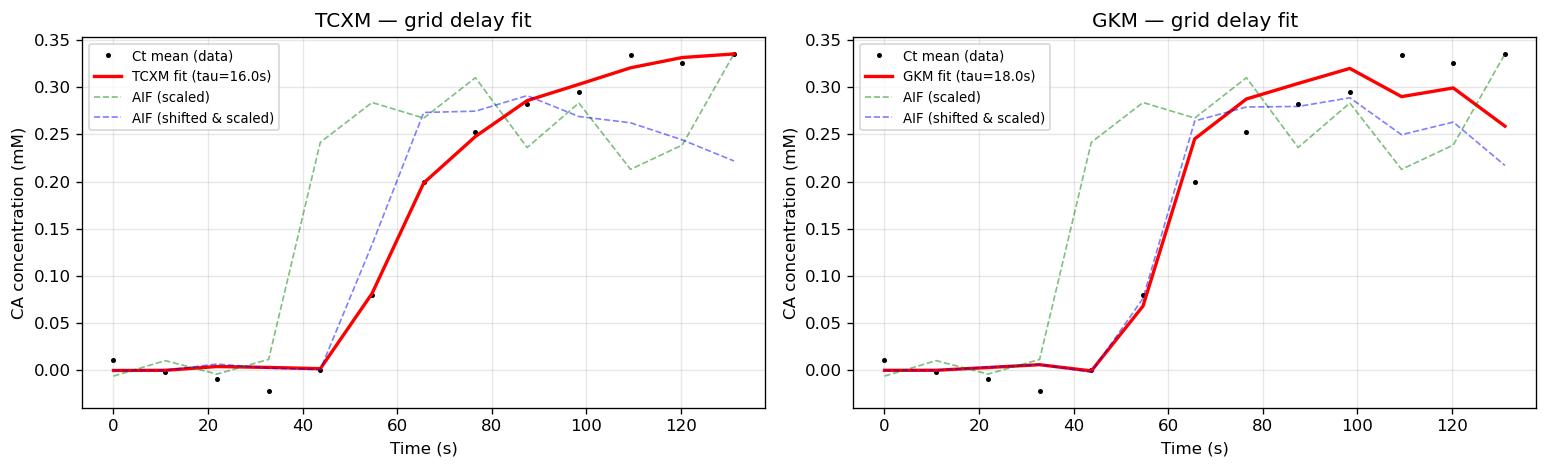

In [27]:
# tau grid — adjust range and spacing based on your data
# coarse (fast):  np.arange(-10, 31, 2.0)   — 21 fits
# fine (slower):  np.arange(-10, 31, 1.0)   — 41 fits
tau_values = np.arange(-10, 50, 2.0)

print(f"Grid search over {len(tau_values)} tau values: "
      f"{tau_values[0]:.0f}s to {tau_values[-1]:.0f}s "
      f"(spacing {tau_values[1]-tau_values[0]:.0f}s)")

print("\nFitting TCXM + grid delay ...")
result_tcxm_grid = fit_roi_with_delay_grid(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_values, seed=0,interp_method="pchip"
)

print("Fitting GKM + grid delay ...")
result_gkm_grid = fit_roi_with_delay_grid(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg,
    tau_values, seed=0,interp_method="pchip"
)

print("\n── TCXM + grid delay ─────────────────────────────")
print(f"  success      : {result_tcxm_grid.success}")
print(f"  cost         : {result_tcxm_grid.best_cost:.4e}")
print(f"  best tau     : {result_tcxm_grid.best_tau:.1f} s")
for name, val in zip(TCXM.param_names, result_tcxm_grid.best_params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM + grid delay ──────────────────────────────")
print(f"  success      : {result_gkm_grid.success}")
print(f"  cost         : {result_gkm_grid.best_cost:.4e}")
print(f"  best tau     : {result_gkm_grid.best_tau:.1f} s")
for name, val in zip(GKM.param_names, result_gkm_grid.best_params):
    print(f"  {name:8s}: {val:.5f}")

# plot cost landscape across tau values
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, result, model, label in zip(
    axes,
    [result_tcxm_grid, result_gkm_grid],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    taus  = sorted(result.per_tau.keys())
    costs = [result.per_tau[tau].cost for tau in taus]

    ax.semilogy(taus, costs, 'bo-', ms=5, lw=1.5)
    ax.axvline(result.best_tau, color='r', lw=2,
               label=f'Best tau = {result.best_tau:.1f}s')
    ax.set_xlabel('Tau (s)')
    ax.set_ylabel('Cost (RSS, log scale)')
    ax.set_title(f'{label} — cost landscape across tau')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# plot fits at best tau
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

for ax, result, model, label in zip(
    axes,
    [result_tcxm_grid, result_gkm_grid],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    shifted_aif_best = shift_aif(aif, result.best_tau, t, acq,method="pchip")
    Ct_pred_best     = model.fn(result.best_params, t, shifted_aif_best)

    ax.plot(t, Ct_sig_mean,  'k.', ms=4, label='Ct mean (data)')
    ax.plot(t, Ct_pred_best, 'r-', lw=2,
            label=f'{label} fit (tau={result.best_tau:.1f}s)')
    ax.plot(t, aif * Ct_sig_mean.max() / aif.max(),
            'g--', lw=1, alpha=0.5, label='AIF (scaled)')
    ax.plot(t, shifted_aif_best * Ct_sig_mean.max() / aif.max(),
            'b--', lw=1, alpha=0.5, label='AIF (shifted & scaled)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CA concentration (mM)')
    ax.set_title(f'{label} — grid delay fit')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model fitting with AIF time delay — continuous optimisation

Continuous tau bounds: [-10.0, 50.0] s

Fitting TCXM + continuous delay ...
Fitting GKM + continuous delay ...

── TCXM + continuous delay ───────────────────────
  success      : True
  cost         : 1.2194e-03
  best tau     : 15.361 s
  ve      : 0.25492
  vp      : 0.06959
  fp      : 0.01961
  ps      : 0.00097

── GKM + continuous delay ────────────────────────
  success      : True
  cost         : 1.4159e-02
  best tau     : 17.960 s
  Ktrans  : 0.03333
  ve      : 0.50000
  vp      : 0.07423


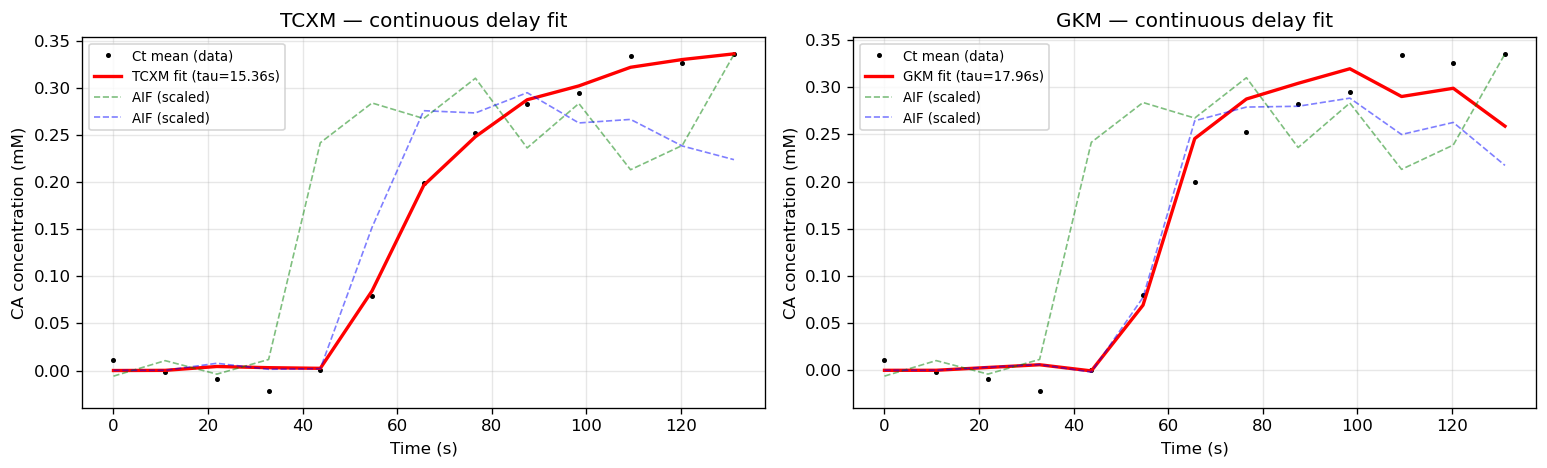

In [28]:
# tau bounds — adjust based on your data and expected delay range
TAU_LB = -10.0   # s
TAU_UB =  50.0   # s
TAU_P0 =   0.0   # s — initial guess

print(f"Continuous tau bounds: [{TAU_LB}, {TAU_UB}] s")

print("\nFitting TCXM + continuous delay ...")
result_tcxm_cont = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, TCXM, acq, subject, cfg, roi_cfg,
    tau_lb=TAU_LB, tau_ub=TAU_UB, tau_p0=TAU_P0, seed=0,interp_method="pchip"
)

print("Fitting GKM + continuous delay ...")
result_gkm_cont = fit_roi_with_delay_continuous(
    sig_4d, lesion_ROI, aif, t, GKM, acq, subject, cfg, roi_cfg,
    tau_lb=TAU_LB, tau_ub=TAU_UB, tau_p0=TAU_P0, seed=0,interp_method="pchip"
)

print("\n── TCXM + continuous delay ───────────────────────")
print(f"  success      : {result_tcxm_cont.success}")
print(f"  cost         : {result_tcxm_cont.best_cost:.4e}")
print(f"  best tau     : {result_tcxm_cont.best_tau:.3f} s")
for name, val in zip(TCXM.param_names, result_tcxm_cont.best_params):
    print(f"  {name:8s}: {val:.5f}")

print("\n── GKM + continuous delay ────────────────────────")
print(f"  success      : {result_gkm_cont.success}")
print(f"  cost         : {result_gkm_cont.best_cost:.4e}")
print(f"  best tau     : {result_gkm_cont.best_tau:.3f} s")
for name, val in zip(GKM.param_names, result_gkm_cont.best_params):
    print(f"  {name:8s}: {val:.5f}")

# plot continuous delay fits
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

for ax, result, model, label in zip(
    axes,
    [result_tcxm_cont, result_gkm_cont],
    [TCXM, GKM],
    ['TCXM', 'GKM'],
):
    shifted_aif_best = shift_aif(aif, result.best_tau, t, acq,method="pchip")
    Ct_pred_best     = model.fn(result.best_params, t, shifted_aif_best)

    ax.plot(t, Ct_sig_mean,  'k.', ms=4, label='Ct mean (data)')
    ax.plot(t, Ct_pred_best, 'r-', lw=2,
            label=f'{label} fit (tau={result.best_tau:.2f}s)')
    ax.plot(t, aif * Ct_sig_mean.max() / aif.max(),
            'g--', lw=1, alpha=0.5, label='AIF (scaled)')
    ax.plot(t, shifted_aif_best * Ct_sig_mean.max() / aif.max(),
            'b--', lw=1, alpha=0.5, label='AIF (scaled)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('CA concentration (mM)')
    ax.set_title(f'{label} — continuous delay fit')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Cost comparison — no delay vs grid vs continuous

In [29]:
# summary table
print(f"{'Method':<30} {'Model':<8} {'Cost':>12} {'Tau (s)':>10} {'Success'}")
print("-" * 70)

rows = [
    ("No delay",         "TCXM", result_tcxm.cost,           None,                         result_tcxm.success),
    ("No delay",         "GKM",  result_gkm.cost,            None,                         result_gkm.success),
    ("Grid delay",       "TCXM", result_tcxm_grid.best_cost, result_tcxm_grid.best_tau,    result_tcxm_grid.success),
    ("Grid delay",       "GKM",  result_gkm_grid.best_cost,  result_gkm_grid.best_tau,     result_gkm_grid.success),
    ("Continuous delay", "TCXM", result_tcxm_cont.best_cost, result_tcxm_cont.best_tau,    result_tcxm_cont.success),
    ("Continuous delay", "GKM",  result_gkm_cont.best_cost,  result_gkm_cont.best_tau,     result_gkm_cont.success),
]

for method, model, cost, tau, success in rows:
    tau_str = f"{tau:.2f}" if tau is not None else "—"
    print(f"{method:<30} {model:<8} {cost:>12.4e} {tau_str:>10} {success}")

Method                         Model            Cost    Tau (s) Success
----------------------------------------------------------------------
No delay                       TCXM       5.3180e-03          — True
No delay                       GKM        8.7954e-02          — True
Grid delay                     TCXM       1.2509e-03      16.00 True
Grid delay                     GKM        1.4160e-02      18.00 True
Continuous delay               TCXM       1.2194e-03      15.36 True
Continuous delay               GKM        1.4159e-02      17.96 True


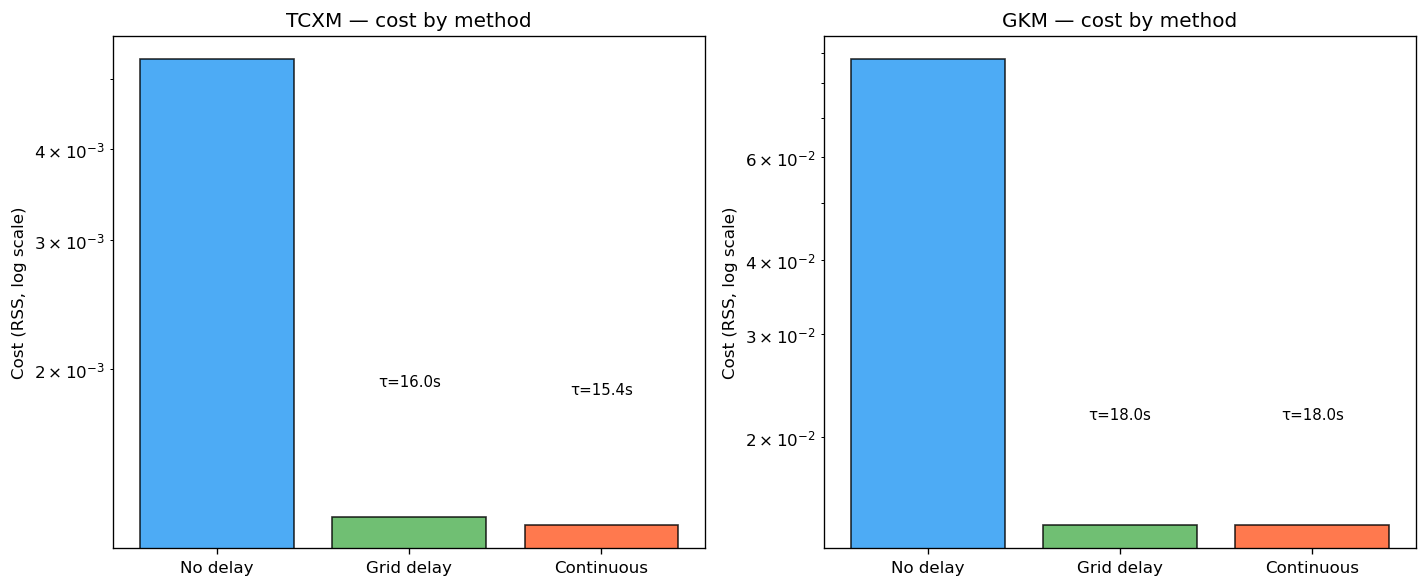

In [30]:
# bar chart of costs
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['No delay', 'Grid delay', 'Continuous']

for ax, model_label, costs_list, tau_list in zip(
    axes,
    ['TCXM', 'GKM'],
    [
        [result_tcxm.cost,
         result_tcxm_grid.best_cost,
         result_tcxm_cont.best_cost],
        [result_gkm.cost,
         result_gkm_grid.best_cost,
         result_gkm_cont.best_cost],
    ],
    [
        [None,
         result_tcxm_grid.best_tau,
         result_tcxm_cont.best_tau],
        [None,
         result_gkm_grid.best_tau,
         result_gkm_cont.best_tau],
    ],
):
    bars = ax.bar(methods, costs_list,
                  color=['#2196F3', '#4CAF50', '#FF5722'],
                  alpha=0.8, edgecolor='black')
    ax.set_yscale('log')
    ax.set_ylabel('Cost (RSS, log scale)')
    ax.set_title(f'{model_label} — cost by method')
    ax.grid(True, alpha=0.3, axis='y')

    # annotate bars with tau value
    for bar, tau in zip(bars, tau_list):
        if tau is not None:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.5,
                    f'τ={tau:.1f}s',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

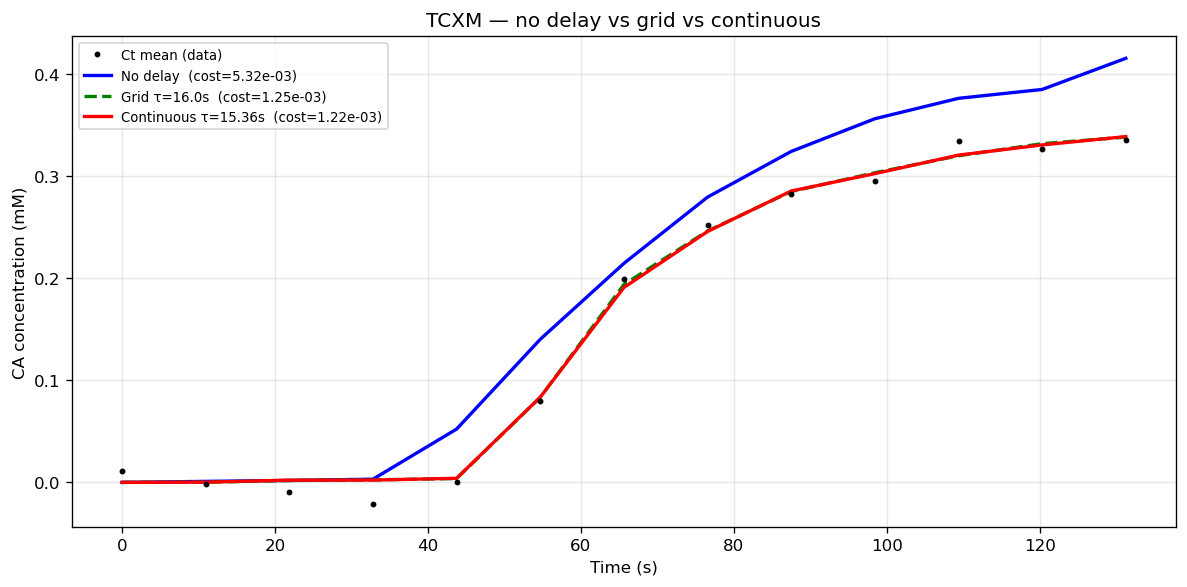

[1.50363346e-05 1.89404435e-04 1.80441929e-03 2.43469670e-03
 3.75449388e-03 8.32175741e-02 1.93698572e-01 2.46069071e-01
 2.84737986e-01 3.03052845e-01 3.19710746e-01 3.31533639e-01
 3.37987305e-01]


In [31]:
# overlay all fits on one plot for TCXM
Ct_sig_mean = _aggregate_roi_signal(sig_4d, lesion_ROI, acq, subject, roi_cfg)[0]

Ct_nodelay = TCXM.fn(result_tcxm.params, t, aif)
Ct_grid    = TCXM.fn(result_tcxm_grid.best_params, t,
                      shift_aif(aif, result_tcxm_grid.best_tau, t, acq))
Ct_cont    = TCXM.fn(result_tcxm_cont.best_params, t,
                      shift_aif(aif, result_tcxm_cont.best_tau, t, acq))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, Ct_sig_mean, 'k.', ms=5, zorder=5, label='Ct mean (data)')
ax.plot(t, Ct_nodelay,  'b-',  lw=2, label=f'No delay  (cost={result_tcxm.cost:.2e})')
ax.plot(t, Ct_grid,     'g--', lw=2,
        label=f'Grid τ={result_tcxm_grid.best_tau:.1f}s  '
              f'(cost={result_tcxm_grid.best_cost:.2e})')
ax.plot(t, Ct_cont,     'r-',  lw=2,
        label=f'Continuous τ={result_tcxm_cont.best_tau:.2f}s  '
              f'(cost={result_tcxm_cont.best_cost:.2e})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('CA concentration (mM)')
ax.set_title('TCXM — no delay vs grid vs continuous')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(Ct_grid)